In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # use GPU 1



UsageError: Line magic function `%%capture` not found.


In [2]:
# OLD (broken):
# from dingo.core.models import PosteriorModel
# main_pm = PosteriorModel(device="cuda", model_filename="...", load_training_info=False)

# NEW:
from dingo.core.posterior_models.build_model import build_model_from_kwargs

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/imbh_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)




WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.


# Single

In [16]:
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

cm=500.0

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
asd_dataset = ASDDataset(file_name=asd_fname)
injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

intrinsic_parameters = {
    "chirp_mass": cm,
    "mass_ratio": 0.8,
    "a_1": .3,
    "a_2": .5,
    "tilt_1": 0.,
    "tilt_2": 0.,
    "phi_jl": 0.,
    "phi_12": 0.
}

extrinsic_parameters = {
    'phase': 0.,
    'theta_jn': 2.3,
    'geocent_time': 0.,
    'luminosity_distance': 1000.,
    'ra': 0.,
    'dec': 0.,
    'psi': 0.,
}

theta = {**intrinsic_parameters, **extrinsic_parameters}
strain_data = injection_generator.injection(theta)
# Returns dict with keys: 'waveform', 'parameters', 'extrinsic_parameters', 'asd'

Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.278428440301053e+33, 1.0227427522408427e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.


In [17]:
from dingo.gw.inference.gw_samplers import  GWSampler
sampler =GWSampler(model=main_pm)
sampler.context = strain_data
sampler.run_sampler(num_samples=50_000, batch_size=10_000)
result = sampler.to_result()
#result.plot_corner(parameters=["chirp_mass", "mass_ratio", "luminosity_distance"])

Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



In [18]:
import numpy as np
samples = result.samples["chirp_mass"]

# percentiles
print(np.percentile(samples, [0.1, 99.9]))

[498.09838162 502.34454562]


# Array

In [3]:
import numpy as np
import itertools
import os
import pickle

# ============================================================
# Parameter grid
# ============================================================

chirp_masses = np.arange(100, 701, 10)


print(chirp_masses)
print(len(chirp_masses))


[100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270
 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450
 460 470 480 490 500 510 520 530 540 550 560 570 580 590 600 610 620 630
 640 650 660 670 680 690 700]
61


## Mass ratio 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 1.0,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 5.1 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



...


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.576017371796195e+33, 1.576017371796195e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.5988582032715024e+33, 1.5988582032715024e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



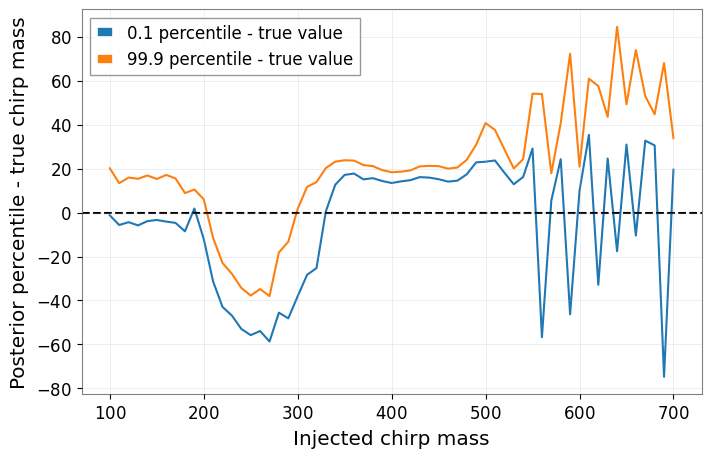

In [5]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.99

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.99,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 5.3 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



...


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.583961056006717e+33, 1.5681214454466496e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.6069170133401478e+33, 1.5908478432067463e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



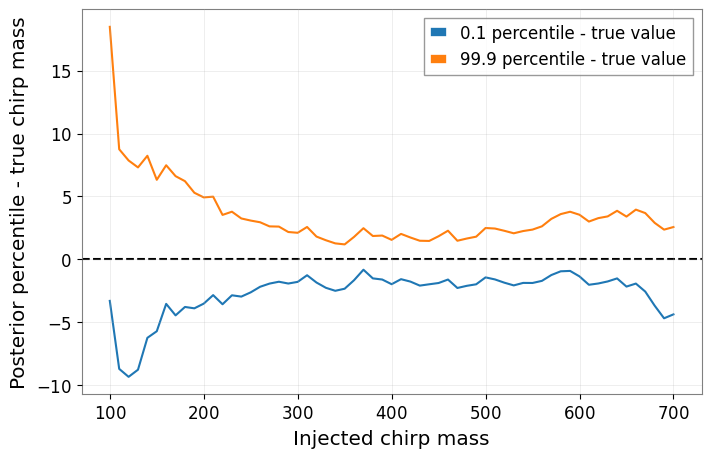

In [6]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.95

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.95,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 5.3 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



...


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.6170660534204153e+33, 1.5362127507493945e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.640501793325059e+33, 1.5584767036588059e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



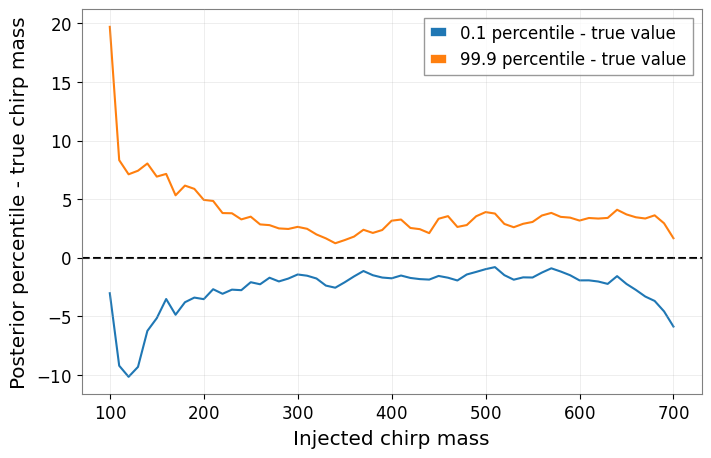

In [5]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.8

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.8,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.


...


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.7642312476154535e+33, 1.411384998092363e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (1.7897998164214748e+33, 1.4318398531371798e+33, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



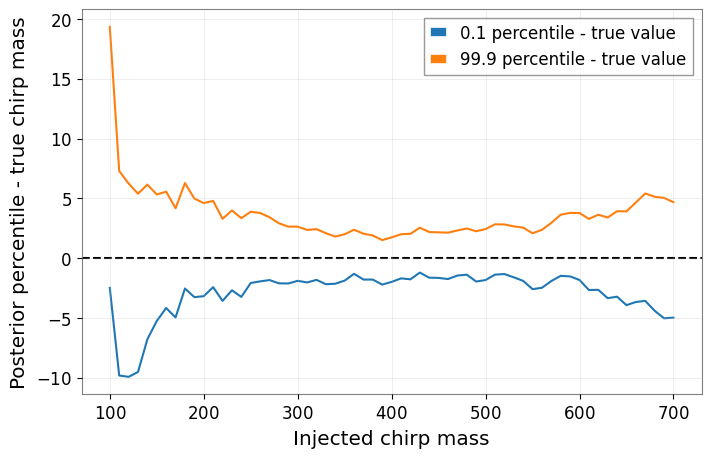

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.4

In [11]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.4,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

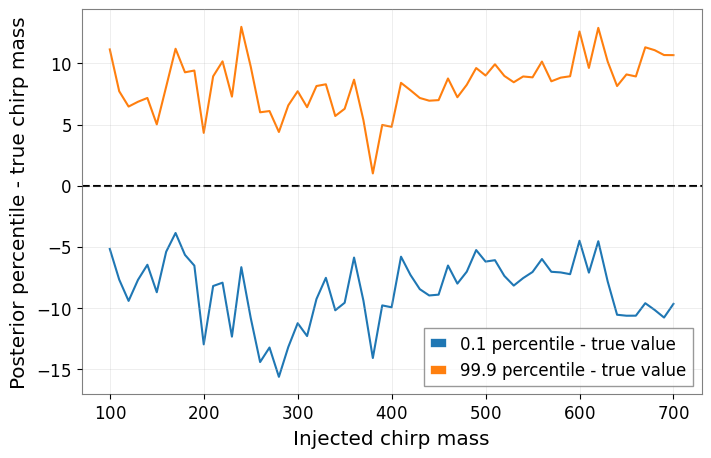

In [12]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.21

In [9]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.21,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

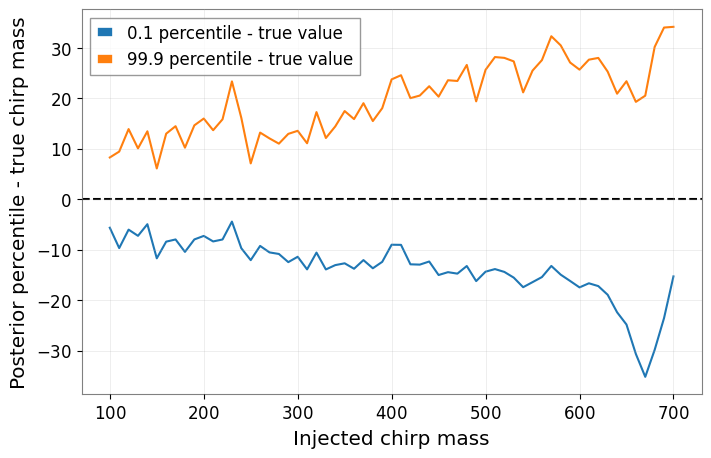

In [10]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Massratio 0.2

In [ ]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset
from dingo.gw.inference.gw_samplers import  GWSampler
injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

# ============================================================
# Mass array
# ============================================================

chirp_masses = np.arange(100, 701, 10)

lower_errors = []
upper_errors = []

for cm in chirp_masses:

    injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
    asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
    asd_dataset = ASDDataset(file_name=asd_fname)
    injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

    intrinsic_parameters = {
        "chirp_mass": cm,
        "mass_ratio": 0.2,
        "a_1": .3,
        "a_2": .5,
        "tilt_1": 0.,
        "tilt_2": 0.,
        "phi_jl": 0.,
        "phi_12": 0.
    }

    extrinsic_parameters = {
        'phase': 0.,
        'theta_jn': 2.3,
        'geocent_time': 0.,
        'luminosity_distance': 1000.,
        'ra': 0.,
        'dec': 0.,
        'psi': 0.,
    }

    theta = {**intrinsic_parameters, **extrinsic_parameters}
    strain_data = injection_generator.injection(theta)


    # Run inference
    sampler = GWSampler(model=main_pm)
    sampler.context = strain_data
    sampler.run_sampler(
        num_samples=50_000,
        batch_size=10_000,
    )

    result = sampler.to_result()

    samples = result.samples["chirp_mass"]

    # 0.1% and 99.9% quantiles
    q_low, q_high = np.percentile(samples, [0.1, 99.9])

    # Difference from injected value
    lower_errors.append(q_low - cm)
    upper_errors.append(q_high - cm)

# Convert to arrays
lower_errors = np.array(lower_errors)
upper_errors = np.array(upper_errors)

Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.


...


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (3.737431597195158e+33, 7.474863194390315e+32, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.0 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Generation with parameters (3.7915972725168257e+33, 7.583194545033651e+32, 0.0, 0.0, 0.3, 0.0, 0.0, 0.5, 3.085677581491367e+24, 2.3, 0.0, 0.0, 0.0, 0.0, 0.5, 6.0, 256.0, 20.0, None, 101) likely numerically unstable due to multibanding, turn off multibanding.
Running sampler to generate 50000 samples.
Done. This took 5.1 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



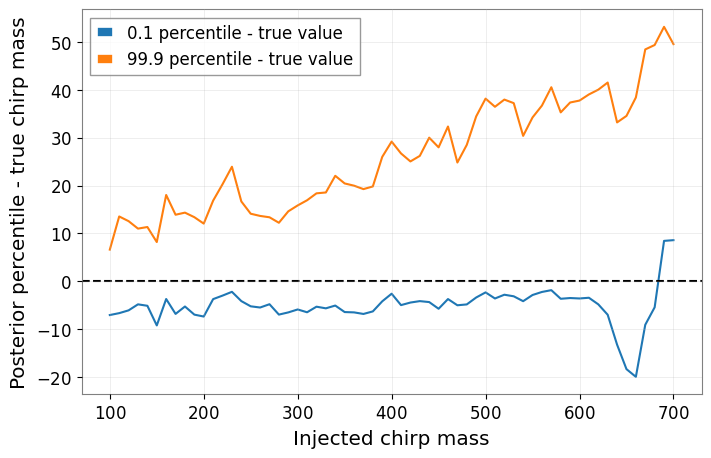

In [7]:

plt.figure(figsize=(8, 5))

plt.plot(
    chirp_masses,
    lower_errors,
    label="0.1 percentile - true value",
)

plt.plot(
    chirp_masses,
    upper_errors,
    label="99.9 percentile - true value",
)

plt.axhline(0, color="k", linestyle="--")

plt.xlabel("Injected chirp mass")
plt.ylabel("Posterior percentile - true chirp mass")
plt.legend()
plt.grid(alpha=0.3)

plt.show()